# Unidad 2: Procesos de Calidad, Limpieza y Transformación en Python
### Procesamiento de Datos (Nivel 4)
**Carrera de Ciencia de Datos** — Modalidad En Línea
**Docente:** Galo Valverde

---

> La manipulación sistemática de datos consume el **80% del tiempo** de un proyecto analítico.

Esta unidad se centra en el preprocesamiento y la transformación avanzada de datos: calidad bajo el
estándar **ISO 8000**, perfilamiento preventivo (*data profiling*), Análisis Exploratorio de Datos (EDA),
limpieza científica (faltantes, duplicados, inconsistencias), transformaciones (normalización,
estandarización, codificación), detección de outliers (IQR, Z-Score), y automatización mediante
**Pipelines** reproducibles de Scikit-Learn.

**Competencias clave:**
- Medir y calificar el nivel de calidad de los datos de forma cuantitativa (ISO 8000).
- Tratar valores faltantes y nulos mediante imputaciones estadísticas o filtrados eficientes.
- Normalizar, estandarizar y escalar características continuas.
- Detectar y aislar valores atípicos (outliers) con IQR y Z-Score.
- Diseñar pipelines de preprocesamiento reproducibles y ejecutables automáticamente.


In [1]:
# Dependencias de la unidad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Entorno listo.")


Entorno listo.


## 0. Dataset de trabajo: un conjunto de datos "sucio"

Para practicar cada técnica de la unidad generamos un dataset sintético de estudiantes/empleados
con los problemas típicos de calidad que se describen en las diapositivas: valores faltantes,
duplicados exactos y parciales, inconsistencias lógicas (edades negativas, fechas futuras) y outliers.


In [2]:
# Generación de un dataset sintético con problemas de calidad reales
n = 500

ciudades = np.random.choice(["Quito", "Guayaquil", "Cuenca"], n, p=[0.4, 0.4, 0.2])
generos = np.random.choice(["M", "F"], n)
edades = np.random.randint(18, 60, n).astype(float)
ingresos = np.random.normal(1200, 350, n).round(2)

df = pd.DataFrame({
    "Dni": [f"{1000000000 + i}" for i in range(n)],
    "Nombre": [f"Persona_{i}" for i in range(n)],
    "Edad": edades,
    "Ingresos": ingresos,
    "Ciudad": ciudades,
    "Genero": generos,
    "FechaRegistro": pd.date_range("2023-01-01", periods=n, freq="D")
})

# Inyectar valores faltantes (MCAR aproximado)
faltantes_idx = np.random.choice(df.index, size=40, replace=False)
df.loc[faltantes_idx, "Edad"] = np.nan
faltantes_idx2 = np.random.choice(df.index, size=25, replace=False)
df.loc[faltantes_idx2, "Ingresos"] = np.nan

# Inyectar inconsistencias lógicas
df.loc[df.sample(5, random_state=1).index, "Edad"] = -5          # edad negativa
df.loc[df.sample(5, random_state=2).index, "FechaRegistro"] = pd.Timestamp("2030-01-01")  # fecha futura

# Inyectar outliers extremos en Ingresos
df.loc[df.sample(6, random_state=3).index, "Ingresos"] = np.random.choice([9500, 10200, -300], 6)

# Inyectar duplicados exactos y parciales
df = pd.concat([df, df.iloc[[0, 1, 2]]], ignore_index=True)         # duplicados exactos
fila_parcial = df.iloc[3].copy()
fila_parcial["Nombre"] = fila_parcial["Nombre"] + " (dup)"           # duplicado parcial por Dni
df = pd.concat([df, pd.DataFrame([fila_parcial])], ignore_index=True)

print("Dimensión del dataset sucio:", df.shape)
df.head()


Dimensión del dataset sucio: (504, 7)


,Dni,Nombre,Edad,Ingresos,Ciudad,Genero,FechaRegistro
0,1000000000,Persona_0,NaN,1215.15,Quito,F,2023-01-01
1,1000000001,Persona_1,23.0,1560.67,Cuenca,M,2023-01-02
2,1000000002,Persona_2,20.0,1252.98,Guayaquil,M,2023-01-03
3,1000000003,Persona_3,24.0,1501.98,Guayaquil,M,2023-01-04
4,1000000004,Persona_4,25.0,1390.63,Quito,M,2023-01-05


## 1. Calidad de Datos — ISO 8000

Seis dimensiones de calidad definen la viabilidad del modelado:

| Dimensión | Descripción | Ejemplo práctico |
|---|---|---|
| **Exactitud** | Grado en que los datos coinciden con el valor real del mundo físico o de negocio | Un DNI debe tener exactamente 10 dígitos |
| **Completitud** | Presencia de todos los atributos requeridos (evita celdas vacías) | Sin campos obligatorios en blanco |
| **Consistencia** | Ausencia de contradicciones lógicas entre tablas o sistemas relacionados | No mezclar escalas o unidades entre sistemas |
| **Coherencia semántica** | Alineamiento en escalas, formatos y unidades de medida | No mezclar fechas `AAAA-MM-DD` con `DD/MM/AAAA` |
| **Vigencia** | Grado de actualidad y relevancia temporal del dato | Datos recientes vs. obsoletos |
| **Trazabilidad (linaje)** | Capacidad de reconstruir la historia del dato desde su origen | Timestamps para auditar cargas incrementales |


## 1.1 Perfilamiento de Datos (Data Profiling)

El perfilamiento es el proceso sistemático de examinar las fuentes de datos, recopilar estadísticas
descriptivas e identificar patrones lógicos para diagnosticar la salud del dataset **antes** de
transformarlo.


In [3]:
# Auditoría estructural básica
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Dni            504 non-null    str           
 1   Nombre         504 non-null    str           
 2   Edad           463 non-null    float64       
 3   Ingresos       479 non-null    float64       
 4   Ciudad         504 non-null    str           
 5   Genero         504 non-null    str           
 6   FechaRegistro  504 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 41.7 KB
None


In [4]:
# Estadísticas descriptivas de variables numéricas
df.describe()


,Edad,Ingresos,FechaRegistro
count,463.000000,479.000000,504
mean,38.123110,1243.322797,2023-09-28 00:08:34.285714
min,-5.000000,-300.000000,2023-01-01 00:00:00
25%,27.000000,955.740000,2023-05-02 18:00:00
50%,39.000000,1215.150000,2023-09-07 12:00:00
75%,49.000000,1467.245000,2024-01-12 06:00:00
max,59.000000,10200.000000,2030-01-01 00:00:00
std,12.800668,779.731076,NaN


In [5]:
# Porcentaje de valores faltantes por columna
missing_pct = df.isnull().mean() * 100
print("Faltantes por columna (%):")
print(missing_pct[missing_pct > 0])


Faltantes por columna (%):
Edad        8.134921
Ingresos    4.960317
dtype: float64


In [6]:
# Registros completamente duplicados
duplicated_count = df.duplicated().sum()
print(f"Filas idénticas repetidas: {duplicated_count}")


Filas idénticas repetidas: 3


## 2. Estadística Descriptiva

### Medidas de tendencia central
- **Media aritmética** — centro de masa matemático, sensible a valores extremos.
- **Mediana (Q2)** — valor central; altamente robusta ante atípicos.
- **Moda** — valor de mayor frecuencia; clave para variables categóricas.

### Asimetría y sesgo
- **Distribución simétrica**: media, mediana y moda coinciden.
- **Sesgo positivo** (a la derecha): Media > Mediana. Común en salarios/ingresos.
- **Sesgo negativo** (a la izquierda): Media < Mediana.
- Un sesgo severo requiere transformaciones logarítmicas antes del modelado.

### Medidas de dispersión
- **Rango** = máximo − mínimo.
- **Cuartiles (Q1, Q2, Q3)** — segmentan la muestra en cuatro partes del 25%.
- **IQR = Q3 − Q1** — dispersión del 50% central, insensible a outliers.
- **Varianza (s²) y desviación estándar (s)** — dispersión respecto a la media; regla empírica: ~68% de los datos cae a ±1 std, ~95% a ±2 std.
- **Coeficiente de variación**: `CV = (s / Media) * 100` — permite comparar variabilidad entre variables de distintas unidades.


In [7]:
# Tendencia central y sesgo sobre Ingresos (ignorando NaN)
media = df["Ingresos"].mean()
mediana = df["Ingresos"].median()
moda = df["Ingresos"].mode().iloc[0]

print(f"Media:   {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda:    {moda:.2f}")
print("Sesgo positivo (Media > Mediana)" if media > mediana else "Sesgo negativo o simétrico")


Media:   1243.32
Mediana: 1215.15
Moda:    -300.00
Sesgo positivo (Media > Mediana)


In [8]:
# Medidas de dispersión sobre Ingresos
Q1 = df["Ingresos"].quantile(0.25)
Q3 = df["Ingresos"].quantile(0.75)
IQR = Q3 - Q1
std = df["Ingresos"].std()
cv = (std / media) * 100

print(f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
print(f"Desviación estándar: {std:.2f}")
print(f"Coeficiente de variación: {cv:.2f}%")


Q1=955.74  Q3=1467.24  IQR=511.50
Desviación estándar: 779.73
Coeficiente de variación: 62.71%


## 2.2 Visualización Exploratoria

Cuatro gráficos indispensables en EDA:

- **Histogramas** (`sns.histplot`) — revelan forma, multimodalidad y simetría de la distribución.
- **Boxplots** (`sns.boxplot`) — mediana, cuartiles y outliers de forma compacta.
- **Scatter plots** (`sns.scatterplot`) — relaciones bivariadas.
- **Heatmaps de correlación** (`sns.heatmap`) — matriz de Pearson/Spearman para aislar colinealidades.


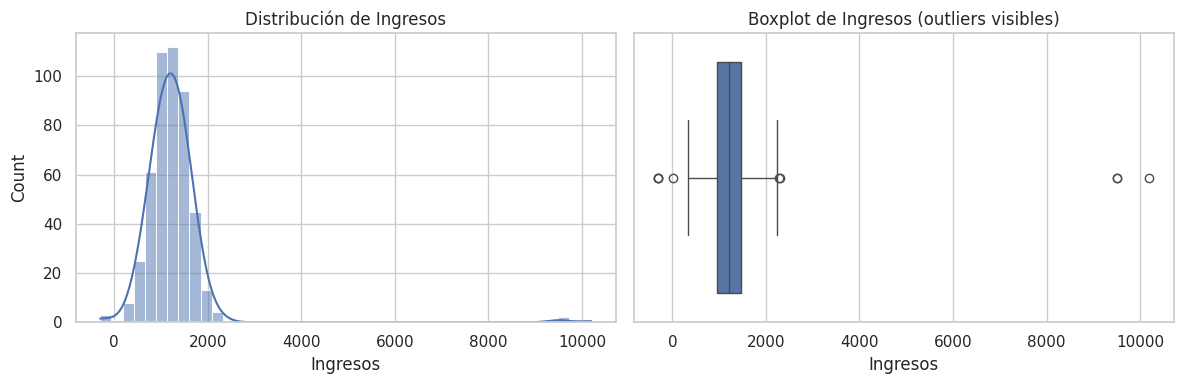

In [9]:
# Histograma y boxplot de Ingresos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Ingresos"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de Ingresos")

sns.boxplot(x=df["Ingresos"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de Ingresos (outliers visibles)")

plt.tight_layout()
plt.show()


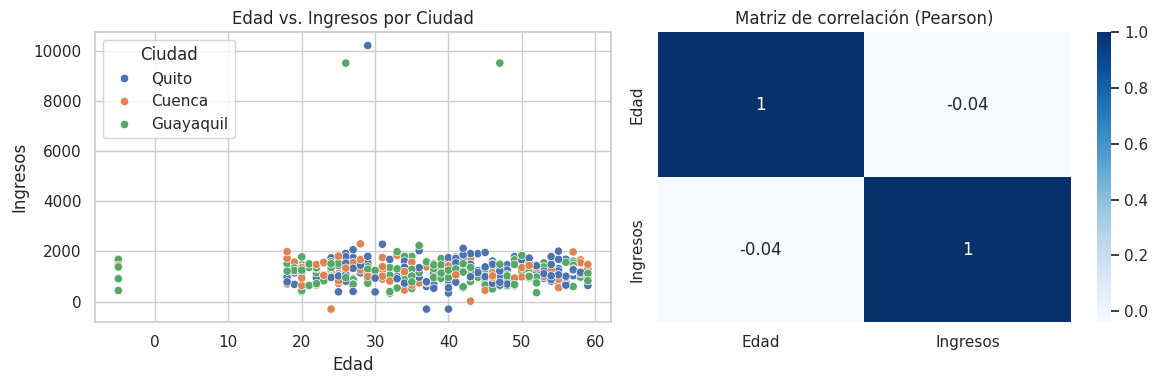

In [10]:
# Scatter plot Edad vs Ingresos, y heatmap de correlación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=df, x="Edad", y="Ingresos", hue="Ciudad", ax=axes[0])
axes[0].set_title("Edad vs. Ingresos por Ciudad")

corr = df[["Edad", "Ingresos"]].corr(method="pearson")
sns.heatmap(corr, annot=True, cmap="Blues", ax=axes[1])
axes[1].set_title("Matriz de correlación (Pearson)")

plt.tight_layout()
plt.show()


## 3. Valores Faltantes

### Tipología (Rubin, 1976)
- **MCAR** (Missing Completely at Random) — la falta es puramente aleatoria.
- **MAR** (Missing at Random) — la probabilidad de faltar se relaciona con otra variable observada.
- **MNAR** (Missing Not at Random) — la probabilidad de faltar depende del propio valor oculto.

### Estrategias de mitigación
- **Eliminación por listas (listwise deletion)** — solo viable si los faltantes son <5% del total en MCAR.
- **Imputación simple** — media (distribuciones simétricas) o mediana (distribuciones sesgadas).
- **Imputación predictiva/avanzada** — regresión lineal, KNN o árboles.
- **Imputación categórica** — constante representativa ("Desconocido") o la moda.


In [11]:
# Método 1: imputación rápida con Pandas (.fillna)
df_pandas = df.copy()
mediana_edad = df_pandas["Edad"].median()
df_pandas["Edad"] = df_pandas["Edad"].fillna(mediana_edad)
print("Faltantes en Edad tras fillna:", df_pandas["Edad"].isna().sum())


Faltantes en Edad tras fillna: 0


In [12]:
# Método 2: imputación profesional con SimpleImputer (evita data leakage en producción)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
cols_num = ["Edad", "Ingresos"]
df[cols_num] = imputer.fit_transform(df[cols_num])

print("Medianas aprendidas por el imputer:", imputer.statistics_)
print("Faltantes restantes:\n", df[cols_num].isna().sum())


Medianas aprendidas por el imputer: [  39.   1215.15]
Faltantes restantes:
 Edad        0
Ingresos    0
dtype: int64


## 4. Datos Inconsistentes y Duplicados

- **Inconsistencias lógicas**: edades negativas, fechas futuras de eventos pasados, contradicciones semánticas.
- **Duplicados exactos**: filas idénticas por errores de sincronización o fallas de red.
- **Duplicados parciales (entidades)**: mismo cliente registrado con variaciones menores de texto ("Juan Pérez" vs. "J. Pérez").

**Solución práctica en Pandas:**
- Auditar con filtros de máscara booleanos: `df[df['Edad'] < 0]`
- Eliminar duplicados exactos: `df.drop_duplicates(inplace=True)`
- De-duplicación parcial por clave: `df.drop_duplicates(subset=['Dni'], keep='first', inplace=True)`


In [13]:
# Auditoría de inconsistencias lógicas
edades_negativas = df[df["Edad"] < 0]
fechas_futuras = df[df["FechaRegistro"] > pd.Timestamp.today()]

print(f"Registros con edad negativa: {len(edades_negativas)}")
print(f"Registros con fecha futura: {len(fechas_futuras)}")

# Corrección: edades negativas se tratan como faltantes y se re-imputan
df.loc[df["Edad"] < 0, "Edad"] = np.nan
df["Edad"] = df["Edad"].fillna(df["Edad"].median())

# Corrección: fechas futuras se acotan a la fecha de hoy
df.loc[df["FechaRegistro"] > pd.Timestamp.today(), "FechaRegistro"] = pd.Timestamp.today().normalize()

print("Inconsistencias corregidas.")


Registros con edad negativa: 5
Registros con fecha futura: 5
Inconsistencias corregidas.


In [14]:
# Eliminación de duplicados exactos
duplicados_exactos = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicados exactos eliminados: {duplicados_exactos}")

# De-duplicación parcial por clave de negocio (Dni), conservando el primer registro
duplicados_parciales = df.duplicated(subset=["Dni"]).sum()
df = df.drop_duplicates(subset=["Dni"], keep="first").reset_index(drop=True)
print(f"Duplicados parciales (mismo Dni) eliminados: {duplicados_parciales}")
print("Dimensión final tras limpieza de duplicados:", df.shape)


Duplicados exactos eliminados: 3
Duplicados parciales (mismo Dni) eliminados: 1
Dimensión final tras limpieza de duplicados: (500, 7)


## 5. Normalización y Estandarización

### Normalización Min-Max
Comprime los valores dentro de un rango acotado, típicamente [0, 1]:

`x_scaled = (x - x_min) / (x_max - x_min)`

Uso primordial: algoritmos sensibles a la escala que no asumen una distribución específica
(redes neuronales, KNN, SVM, procesamiento de imágenes).

### Estandarización Z-Score
Transforma la variable para media = 0 y desviación estándar = 1:

`z = (x - Media) / Desviación_Estándar`

Más robusta ante outliers extremos que Min-Max; óptima para algoritmos lineales
(regresión, PCA, redes neuronales).

### ¿Por qué escalar?
Sin escalar, una variable con magnitud mayor (ej. `Ingresos` en miles) domina por completo
métricas de distancia frente a una variable de rango pequeño (ej. `Edad`), distorsionando
KNN, SVM, PCA y la convergencia del gradiente descendente.


In [15]:
# Normalización Min-Max con Scikit-Learn
from sklearn.preprocessing import MinMaxScaler

df_scaled = df.copy()
scaler_mm = MinMaxScaler(feature_range=(0, 1))
df_scaled[["Edad_minmax", "Ingresos_minmax"]] = scaler_mm.fit_transform(df[["Edad", "Ingresos"]])

print("Rango aprendido (max - min):", scaler_mm.data_range_)
df_scaled[["Edad", "Edad_minmax", "Ingresos", "Ingresos_minmax"]].head()


Rango aprendido (max - min): [   41. 10500.]


,Edad,Edad_minmax,Ingresos,Ingresos_minmax
0,39.0,0.512195,1215.15,0.144300
1,23.0,0.121951,1560.67,0.177207
2,20.0,0.048780,1252.98,0.147903
3,24.0,0.146341,1501.98,0.171617
4,25.0,0.170732,1390.63,0.161012


In [16]:
# Estandarización Z-Score con Scikit-Learn
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df_scaled[["Edad_z", "Ingresos_z"]] = scaler_std.fit_transform(df[["Edad", "Ingresos"]])

print("Medias aprendidas:", scaler_std.mean_)
print("Varianzas aprendidas:", scaler_std.var_)
df_scaled[["Edad", "Edad_z", "Ingresos", "Ingresos_z"]].head()


Medias aprendidas: [  38.728   1240.79918]
Varianzas aprendidas: [1.30998016e+02 5.80925724e+05]


,Edad,Edad_z,Ingresos,Ingresos_z
0,39.0,0.023765,1215.15,-0.033652
1,23.0,-1.374172,1560.67,0.419676
2,20.0,-1.636285,1252.98,0.015981
3,24.0,-1.286801,1501.98,0.342674
4,25.0,-1.199430,1390.63,0.196581


## 5.1 Codificación de Variables Categóricas (One-Hot)

La mayoría de algoritmos matemáticos solo procesan valores numéricos. Asignar números
secuenciales a categorías (Quito=1, Guayaquil=2, Cuenca=3) induce un orden de magnitud
artificial que no existe y confunde a los modelos. La codificación **One-Hot** evita esa
jerarquía falsa creando una columna binaria por categoría.


In [17]:
# Método 1: get_dummies de Pandas (rápido, para exploración)
df_dummies = pd.get_dummies(df[["Ciudad"]], columns=["Ciudad"], prefix="C")
df_dummies.head()


,C_Cuenca,C_Guayaquil,C_Quito
0,False,False,True
1,True,False,False
2,False,True,False
3,False,True,False
4,False,False,True


In [18]:
# Método 2: OneHotEncoder de Scikit-Learn (recomendado para pipelines de producción)
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ciudad_encoded = encoder.fit_transform(df[["Ciudad"]])
print("Columnas generadas:", encoder.get_feature_names_out(["Ciudad"]))
pd.DataFrame(ciudad_encoded, columns=encoder.get_feature_names_out(["Ciudad"])).head()


Columnas generadas: ['Ciudad_Cuenca' 'Ciudad_Guayaquil' 'Ciudad_Quito']


,Ciudad_Cuenca,Ciudad_Guayaquil,Ciudad_Quito
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0


## 6. Detección de Valores Atípicos (Outliers)

### Método IQR (no paramétrico, robusto)
```
IQR = Q3 - Q1
Límite Inferior = Q1 - 1.5 * IQR
Límite Superior = Q3 + 1.5 * IQR
```
Todo dato fuera de estos límites se clasifica como outlier (visible fuera de los bigotes del boxplot).

### Método Z-Score (para distribuciones aproximadamente normales)
```
z_i = (x_i - Media) / std
```
Bajo la regla empírica, el 99.7% de los datos cae a ±3 desviaciones estándar; `|Z| > 3` se
considera una anomalía estadística extrema.


In [19]:
# Detección de outliers con IQR sobre Ingresos
Q1 = df["Ingresos"].quantile(0.25)
Q3 = df["Ingresos"].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers_iqr = df[(df["Ingresos"] < limite_inf) | (df["Ingresos"] > limite_sup)]
print(f"Límite inferior: {limite_inf:.2f}  |  Límite superior: {limite_sup:.2f}")
print(f"Cantidad de atípicos (IQR): {len(outliers_iqr)}")
outliers_iqr[["Dni", "Ingresos"]]


Límite inferior: 234.14  |  Límite superior: 2181.29
Cantidad de atípicos (IQR): 10


,Dni,Ingresos
37,1000000037,10200.00
130,1000000130,9500.00
143,1000000143,2282.92
157,1000000157,2231.17
191,1000000191,-300.00
239,1000000239,-300.00
280,1000000280,2299.69
291,1000000291,-300.00
420,1000000420,9500.00
441,1000000441,14.05


In [20]:
# Detección de outliers con Z-Score sobre Ingresos
z_scores = np.abs(stats.zscore(df["Ingresos"]))
indices_atipicos = np.where(z_scores > 3)[0]

print("Índices de filas atípicas (Z-Score > 3):", indices_atipicos)

df_limpio = df[z_scores <= 3].reset_index(drop=True)
print("Dimensión original:", df.shape)
print("Dimensión limpia (sin outliers extremos):", df_limpio.shape)


Índices de filas atípicas (Z-Score > 3): [ 37 130 420]
Dimensión original: (500, 7)
Dimensión limpia (sin outliers extremos): (497, 7)


## 7. Automatización con Pipelines

El preprocesamiento manual (celdas sueltas de Jupyter) es un riesgo severo para la
consistencia científica de los modelos. Para garantizar **reproducibilidad**, todas las
transformaciones se encapsulan en un flujo unificado que se aplica de forma idéntica a
entrenamiento, validación, prueba y datos en vivo.

**Flujo secuencial de un pipeline:**
1. **Datos en bruto (raw data)** — entrada sin estructurar.
2. **Imputador de faltantes** (`SimpleImputer`) — trata nulos.
3. **ColumnTransformer** — aplica escaladores (`StandardScaler`/`MinMaxScaler`) a columnas
   numéricas y codificadores (`OneHotEncoder`) a categóricas, en paralelo.
4. **Estimador/modelo predictivo** — recibe la matriz limpia y realiza predicciones.

**Beneficio:** previene la filtración de datos (*data leakage*).


In [21]:
# Pipeline profesional con ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

df_pipeline = df_limpio.copy()

# 1. Transformaciones numéricas: imputar (por si acaso) + estandarizar
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 2. Transformaciones categóricas: imputar con la moda + One-Hot
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 3. Integración en un ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, ["Edad", "Ingresos"]),
    ("cat", cat_transformer, ["Ciudad", "Genero"])
])

# 4. Procesar el dataset de forma unificada y reproducible
X_clean = preprocessor.fit_transform(df_pipeline)

print("Forma de la matriz final lista para modelado:", X_clean.shape)
print("Nombres de las columnas generadas:")
print(preprocessor.get_feature_names_out())


Forma de la matriz final lista para modelado: (497, 7)
Nombres de las columnas generadas:
['num__Edad' 'num__Ingresos' 'cat__Ciudad_Cuenca' 'cat__Ciudad_Guayaquil'
 'cat__Ciudad_Quito' 'cat__Genero_F' 'cat__Genero_M']


## 8. Buenas Prácticas de Ingeniería y Documentación

- **Diccionarios de datos**: detallan nombre físico, tipo de dato (`float64`, `int64`, `object`),
  descripción de negocio y restricciones semánticas de cada columna.
- **Semilla determinista (random seed)**: fijar `random_state=42` en toda división o muestreo
  para garantizar reproducibilidad matemática.
- **Control de versiones de datos (DVC)**: rastrear los estados físicos de los datasets en Git,
  en paralelo al código.
- **Gobernanza y ética**: cumplir rigurosamente con anonimización y protección de datos
  sensibles de los usuarios.


In [22]:
# Ejemplo de diccionario de datos documentado para este dataset
diccionario_de_datos = [
    {"campo": "Dni",            "tipo": "object",   "restriccion": "10 dígitos, clave única de negocio"},
    {"campo": "Nombre",         "tipo": "object",   "restriccion": "Texto libre"},
    {"campo": "Edad",           "tipo": "float64",  "restriccion": "Rango válido: 18-99, sin negativos"},
    {"campo": "Ingresos",       "tipo": "float64",  "restriccion": "USD/mes, valor >= 0"},
    {"campo": "Ciudad",         "tipo": "object",   "restriccion": "Categórica: Quito, Guayaquil, Cuenca"},
    {"campo": "Genero",         "tipo": "object",   "restriccion": "Categórica: M, F"},
    {"campo": "FechaRegistro",  "tipo": "datetime64","restriccion": "No debe ser posterior a la fecha actual"},
]
pd.DataFrame(diccionario_de_datos)


,campo,tipo,restriccion
0,Dni,object,"10 dígitos, clave única de negocio"
1,Nombre,object,Texto libre
2,Edad,float64,"Rango válido: 18-99, sin negativos"
3,Ingresos,float64,"USD/mes, valor >= 0"
4,Ciudad,object,"Categórica: Quito, Guayaquil, Cuenca"
5,Genero,object,"Categórica: M, F"
6,FechaRegistro,datetime64,No debe ser posterior a la fecha actual


## 9. Conclusiones

- La manipulación de datos transforma datos en bruto inconsistentes en **activos de datos**
  listos para el análisis.
- La calidad no es opcional: el perfilamiento sistemático y la limpieza garantizan la robustez
  de los modelos predictivos del negocio.
- La estandarización es un pilar indispensable para algoritmos basados en distancias.
- Encapsular todo el flujo en un **pipeline** asegura reproducibilidad y previene *data leakage*.

**Próximo paso:** Unidad 3 — Procesos ETL, donde se diseñan pipelines robustos para integrar,
combinar e inyectar datos a gran escala procedentes de múltiples bases de datos relacionales
heterogéneas.

---

## Referencias y Enlaces de Consulta

**Enlaces oficiales:**
- Guía de Preprocesamiento de Scikit-Learn: https://scikit-learn.org/stable/modules/preprocessing.html
- Especificaciones del Estándar ISO 8000: https://www.iso.org/standard/70918.html

**Referencias bibliográficas (APA):**
- Caballero Muñoz-Reja, I., Piattini Velthuis, M., Gualo Cejudo, F., Gómez, A. I., Rivas, B., & Merino, J. (2019). *Calidad de Datos* (1ª ed.). Ra-Ma Editorial.
- Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
- Han, J., Kamber, M., & Pei, J. (2023). *Data Mining: Concepts and Techniques* (4th ed.). Morgan Kaufmann.
